In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20250401-20250430.mbp-10.PFE.csv')
df.head()

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,1743494400011096690,1743494400010927943,10,2,12497,A,N,0,25180000000,500,...,0,0,0,9223372036854775807,9223372036854775807,0,0,0,0,PFE
1,1743494400011133612,1743494400010965227,10,2,12497,A,A,0,25420000000,500,...,0,0,0,9223372036854775807,9223372036854775807,0,0,0,0,PFE
2,1743494400012006920,1743494400011840629,10,2,12497,A,B,0,25250000000,100,...,0,0,0,9223372036854775807,9223372036854775807,0,0,0,0,PFE
3,1743494400064927961,1743494400064759616,10,2,12497,A,B,1,25200000000,500,...,0,0,0,9223372036854775807,9223372036854775807,0,0,0,0,PFE
4,1743494400064955767,1743494400064789669,10,2,12497,C,A,0,25420000000,500,...,0,0,0,9223372036854775807,9223372036854775807,0,0,0,0,PFE


## Data pre-process
The data is very messy here. So we only trust the snapshot change in time:
* for each `ts_recv` (each snapshot), it should have one ended line with `flags` = 128 or 130 


What my preprocess do is to check the change of snapshot by `book_diff` \
and reconstruct the events and book state I want in the late for loop


In [3]:
from dataclasses import dataclass
from typing import Literal

N_LEVELS = 5

@dataclass
class BookChange:
    side:        Literal['bid', 'ask']
    level:       int   # 0-indexed position in the book
    price:       int
    size_delta:  int   # positive = added, negative = removed

def parse_side(row, side: str, n_levels: int) -> dict[int, tuple[int, int]]:
    """Extract {price: (level, size)} for one side, skipping empty levels."""
    best = row[f'{side}_px_00']
            
    return {
        int(row[f'{side}_px_{i:02d}']): (int(abs(row[f'{side}_px_{i:02d}']-best)*1e-7)+1, int(row[f'{side}_sz_{i:02d}']))
        for i in range(n_levels)
        if abs(row[f'{side}_px_{i:02d}']-best) < (n_levels-0.5)*1e7 
        # only consider the change in first four queue level (each level is a tick away from the previous one)
        # minus 0.5 to prevent python overflow
    }

def book_diff(old_row, new_row, n_levels: int = N_LEVELS) -> list[BookChange]:
    changes = []

    for side in ('bid', 'ask'):
        old_book = parse_side(old_row, side, n_levels)
        new_book = parse_side(new_row, side, n_levels)

        for price in old_book.keys() | new_book.keys():
            old_level, old_size = old_book.get(price, (None, 0))
            new_level, new_size = new_book.get(price, (None, 0))

            if old_size != new_size:
                # Prefer the new level; fall back to old if price was removed
                level = new_level if new_level is not None else old_level
                changes.append(BookChange(side, level, price, new_size - old_size))

    return changes

The reason why I directly detect the snapshot change is becasue there might be **multiple** change between snapshots\
But the dataset from databento are not availible to detect it

In [4]:
from dataclasses import asdict
state_a = df.iloc[359].to_dict()
state_b = df.iloc[360].to_dict()

changes = book_diff(state_a, state_b)  # → [BookChange('ask', 13, -10)]
event_df = pd.DataFrame([asdict(c) for c in changes])
event_df.head()

,side,level,price,size_delta
0,bid,1,25290000000,100
1,ask,1,25310000000,200


In [5]:

from dataclasses import asdict
from tqdm import tqdm

previous = None
events = []  # collect dicts, concat once at the end
states = []

for ts, temp_df in tqdm(df.groupby('ts_recv', sort=False), total=df['ts_recv'].nunique(), desc='Processing'):

    now = temp_df.iloc[-1].to_dict()
    
    ask = parse_side(now, 'ask', n_levels=N_LEVELS)
    bid = parse_side(now, 'bid', n_levels=N_LEVELS)
    
    best_ask = min(ask.keys())
    best_bid = max(bid.keys())
    
    if previous is not None:
        changes = book_diff(previous, now)        
        if changes:  # skip empty diffs
            reduce_reason = 'T' if (temp_df['action'] == 'T').any() else 'C'
            
            is_create = (best_ask < best_ask_p) or (best_bid > best_bid_p)
            
            for c in changes:
                sd = c.size_delta
                action = ('E' if (is_create and c.level == 1) else 'A') if sd > 0 else reduce_reason
                events.append({
                    'ts_hap': ts, 'ts_con': previous['ts_recv'],
                    'side': c.side, 'level': c.level, 'price': c.price,
                    'size_delta': abs(sd), 'action': action,
                })

            levels = range(-N_LEVELS, N_LEVELS+1)
            state = {lv: 0 for lv in levels}
            state.update({level: size for level, size in ask.values()})
            state.update({-level: size for level, size in bid.values()})

            bid1, ask1 = state[-1], state[1]
            denom = ask1 + bid1
            state['spread'] = int((best_ask - best_bid) * 1e-7)
            state['imb'] = (ask1 - bid1) / denom if denom != 0 else 2
            state['best_px'] = (best_ask + best_bid) / 2 * 1e-9
            states.append(state)

        
    previous = now  # always update, even on first iter
    best_ask_p = best_ask 
    best_bid_p = best_bid
    
event_df = pd.DataFrame(events, columns=['ts_hap', 'ts_con', 'side', 'level', 'price', 'size_delta', 'action'])
states_df = pd.DataFrame(states)
states_df['ts'] = df['ts_recv'].drop_duplicates(ignore_index=True)
states_df.drop(columns=[0], inplace=True)

Processing: 100%|██████████| 6587640/6587640 [14:03<00:00, 7806.28it/s]


In [6]:
event_df

,ts_hap,ts_con,side,level,price,size_delta,action
0,1743494400011133612,1743494400011096690,ask,1,25420000000,500,E
1,1743494400012006920,1743494400011133612,bid,1,25180000000,500,C
2,1743494400012006920,1743494400011133612,bid,1,25250000000,100,E
3,1743494400064955767,1743494400064927961,ask,1,25420000000,500,C
4,1743494400065116969,1743494400064955767,bid,2,25240000000,500,A
...,...,...,...,...,...,...,...
6791474,1746057590941421632,1746057590941080151,bid,1,24340000000,45,C
6791475,1746057590941421632,1746057590941080151,bid,5,24290000000,10,A
6791476,1746057590950981283,1746057590941421632,bid,1,24330000000,85,C
6791477,1746057590991641888,1746057590950981283,bid,1,24330000000,100,C


In [7]:
states_df[(states_df[1]==0)&(states_df[-1]==0)]

,-5,-4,-3,-2,-1,1,2,3,4,5,spread,imb,best_px,ts
1913203,0,0,0,0,0,0,0,0,0,0,0,2.0,9.223372e+09,1744135044090705411
2531621,0,0,0,0,0,0,0,0,0,0,0,2.0,9.223372e+09,1744223378295552873
3365379,0,0,0,0,0,0,0,0,0,0,0,2.0,9.223372e+09,1744385036272805240
4428179,0,0,0,0,0,0,0,0,0,0,0,2.0,9.223372e+09,1744897506544040100
5575177,0,0,0,0,0,0,0,0,0,0,0,2.0,9.223372e+09,1745523537911999053


### Discretelize imbalance

In [8]:
def get_imbalance_bin(series):
    v = series.to_numpy()
    
    # Divide by 0.1 and round to fix floating-point precision issues
    # e.g., -0.1 / 0.1 could be -0.9999... instead of -1.0
    scaled = np.round(v / 0.1, 8)

    result = np.where(
        v == 0,                          # bin 0: exactly zero
        0,
        np.where(
            v < 0,
            np.floor(scaled).astype(int),  # negative: [0.1*i, 0.1*(i+1))
            np.ceil(scaled).astype(int)    # positive: (0.1*(i-1), 0.1*i]
        )
    )
    return result

In [9]:
states_df['imb'] = get_imbalance_bin(states_df['imb'])
states_df

,-5,-4,-3,-2,-1,1,2,3,4,5,spread,imb,best_px,ts
0,0,0,0,0,500,500,0,0,0,0,24,0,2.530000e+01,1743494400011096690
1,0,0,0,0,100,500,0,0,0,0,17,7,2.533500e+01,1743494400011133612
2,0,0,0,0,100,0,0,0,0,0,922337201160,-10,4.611686e+09,1743494400012006920
3,0,0,0,500,100,0,0,0,0,0,922337201160,-10,4.611686e+09,1743494400064927961
4,0,0,0,0,100,0,0,0,0,0,922337201160,-10,4.611686e+09,1743494400064955767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6170118,100,1,0,285,45,851,591,0,0,0,5,9,2.436500e+01,1745939937029048818
6170119,100,1,0,185,45,851,591,0,0,0,5,9,2.436500e+01,1745939937029050438
6170120,10,100,1,0,185,851,591,0,0,0,6,7,2.436000e+01,1745939937029052445
6170121,10,100,1,0,100,851,591,0,0,0,6,8,2.436000e+01,1745939937029054509


### Filter trading hours

In [10]:
import pandas_market_calendars as mcal

def filter_trading_hours(df: pd.DataFrame, ts_col: str = "ts_recv") -> pd.DataFrame:
    """
    filter the first and last 30 min of each trading day
    remaining: 10:00~15:00 each trading day
    """
    # Convert nanosecond UTC to ET
    # ts_et = pd.to_datetime(df[ts_col], unit="ns")
    ts_et = pd.to_datetime(df[ts_col], unit="ns", utc=True).dt.tz_convert("America/New_York")
    
    # Get the date range covered by the data
    start_date = ts_et.dt.date.min()
    end_date   = ts_et.dt.date.max()
    
    # Get the NYSE trading calendar for that range
    nyse = mcal.get_calendar("NYSE")
    schedule = nyse.schedule(
        start_date=start_date.strftime("%Y-%m-%d"),
        end_date=end_date.strftime("%Y-%m-%d")
    )
    
    # schedule gives you market_open and market_close in UTC for each trading day
    # but we will use fixed 9:30-15:30 ET since regular session times don't change
    trading_dates = set(schedule.index.date)
    
    # Build mask: must be a trading day AND within session hours
    date_only = ts_et.dt.date
    time_only = ts_et.dt.time
    
    market_open  = pd.Timestamp("10:00:00").time()
    market_close = pd.Timestamp("15:30:00").time()
    
    is_trading_day   = date_only.apply(lambda d: d in trading_dates)
    is_trading_hours = (time_only >= market_open) & (time_only <= market_close)
    
    mask = is_trading_day & is_trading_hours
    
    return df[mask].reset_index(drop=True)

In [11]:
states_df = filter_trading_hours(states_df, 'ts')
states_df

,-5,-4,-3,-2,-1,1,2,3,4,5,spread,imb,best_px,ts
0,3850,2225,5368,1821,965,873,2486,1893,4525,1742,2,-1,24.800,1743516000018317109
1,2225,5368,1821,965,100,873,2486,1893,4525,1742,1,8,24.805,1743516000018420653
2,2225,5368,1821,965,100,600,2486,1893,4525,1742,1,8,24.805,1743516000018471125
3,2225,5368,1821,965,196,600,2486,1893,4525,1742,1,6,24.805,1743516000018484476
4,2225,5368,1821,965,196,500,2486,1893,4525,1742,1,5,24.805,1743516000018572050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4451875,100,1,0,285,45,851,591,0,0,0,5,9,24.365,1745939937029048818
4451876,100,1,0,185,45,851,591,0,0,0,5,9,24.365,1745939937029050438
4451877,10,100,1,0,185,851,591,0,0,0,6,7,24.360,1745939937029052445
4451878,10,100,1,0,100,851,591,0,0,0,6,8,24.360,1745939937029054509


In [12]:
states_df['spread'].value_counts()

spread
1               3544972
2                833303
3                 38184
4                 11929
5                  7639
                 ...   
922337201433          1
922337201457          1
922337201409          1
922337201405          1
922337201404          1
Name: count, Length: 144, dtype: int64

In [ ]:
from pathlib import Path

directory = Path('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/')

# 2. Find all CSV files (use .rglob('*.csv') to search subfolders too)
csv_files = directory.glob('*.csv')
sorted_files = sorted(csv_files, key=lambda f: f.name.split('-')[3])

# 3. Read and combine into a single DataFrame
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)



[PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20260101-20260131.mbp-10.PFE.csv'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20250901-20250930.mbp-10.PFE.csv'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20250401-20250430.mbp-10.PFE.csv'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20250601-20250630.mbp-10.PFE.csv'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20260201-20260228.mbp-10.PFE.csv'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20250701-20250731.mbp-10.PFE.csv'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20250331.mbp-10.PFE.csv'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20251101-20251130.mbp-10.PFE.csv'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/xnas-itch-20251201-20251231.mbp-10.PFE.csv'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDCM7RR/manifest.json'),
 PosixPath('../data/raw/PFE/XNAS-20260425-UEJBDC

In [ ]:
find the prob
1. divide the events by actions
2. for different action find their happened probability under different state
3. find the time delta distribution under different event and state
4. find the volumn distribution different event and state
5. deep level probability

In [13]:
def get_event_condition(df: pd.DataFrame):
    return (
        # With level: action x level x side = 2 x 2 x 2 = 8 filters
        [
            (df['action'] == action) & (df['level'] == n) & (df['side'] == s)
            for action in ['A', 'C']
            for n in [1, 2]
            for s in ['ask', 'bid']
        ]
        +
        # Without level: action x side = 2 x 2 = 4 filters
        [
            (df['action'] == action) & (df['side'] == s)
            for action in ['T', 'E']
            for s in ['ask', 'bid']
        ]
    )


In [14]:
state_conditions = [
    (states_df['spread'] == s) & (states_df['imb'] == imb) 
    for s in [1, 2, 3, 4, 5]
    for imb in [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
]
len(state_conditions)

105

In [15]:
states_df[state_conditions[0]]

,-5,-4,-3,-2,-1,1,2,3,4,5,spread,imb,best_px,ts
228,1365,1247,1104,2516,4525,200,2992,3025,700,2100,1,-10,24.835,1743516001983248651
229,1365,1247,1104,2516,4525,200,2892,3025,700,2100,1,-10,24.835,1743516002001238264
230,1365,1247,1104,2516,4525,200,2792,3025,700,2100,1,-10,24.835,1743516002003626185
231,1365,1247,1104,2516,3983,200,2792,3025,700,2100,1,-10,24.835,1743516002003658801
232,1365,1247,1104,2516,3983,200,2692,3025,700,2100,1,-10,24.835,1743516002055138044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450407,0,43,43,43,43,1,0,0,0,100,1,-10,24.395,1745939863988390827
4450408,0,43,43,43,98,1,0,0,0,100,1,-10,24.395,1745939863988427550
4450409,0,43,43,43,43,1,0,0,0,100,1,-10,24.395,1745939863988616743
4450410,0,43,43,43,98,1,0,0,0,100,1,-10,24.395,1745939863988619995


In [19]:
current_states = states_df[state_conditions[0]]
rng = np.random.default_rng(seed=42)
init_idx = rng.choice(current_states.index, size=100)
states_df.iloc[init_idx]

,-5,-4,-3,-2,-1,1,2,3,4,5,spread,imb,best_px,ts
504753,1100,1200,3313,1207,3031,109,2006,3262,1700,1800,1,-10,23.365,1743782935469442623
3510756,110,610,311,620,610,20,710,130,120,700,1,-10,22.775,1745249425731127926
3062544,2700,3202,2035,3604,4813,200,2199,2433,2306,2700,1,-10,22.365,1744815720825989285
2133627,2900,2708,5776,3000,5683,209,1300,2403,5100,2722,1,-10,21.735,1744302654854490327
2104269,2518,5350,2856,3300,2450,17,3503,2694,5100,6278,1,-10,21.515,1744301320170934276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1264729,3400,5900,3680,3000,2084,100,3102,6105,3100,2800,1,-10,21.905,1744124191437668945
1058242,3308,5509,2500,2300,2200,100,3644,2424,5404,3604,1,-10,22.615,1744047302960684934
3144906,2771,2400,3200,3000,4330,60,3566,3832,3794,16700,1,-10,22.365,1744825607487737361
2979343,4700,3700,6833,3412,8546,200,5454,8065,5117,4506,1,-10,22.195,1744736518170248498


In [15]:
ts_con = states_df[state_conditions[0]]['ts']
current_state_events = event_df[event_df['ts_con'].isin(ts_con)]
cse = current_state_events[get_event_condition(current_state_events)[0]]
cse

,ts_hap,ts_con,side,level,price,size_delta,action
38745,1743516002003658801,1743516002003626185,ask,1,24820000000,100,A
38941,1743516005093174587,1743516005093157974,ask,1,24830000000,665,A
38946,1743516005093211632,1743516005093193843,ask,1,24830000000,375,A
38947,1743516005093213258,1743516005093211632,ask,1,24830000000,309,A
38950,1743516005093383688,1743516005093358853,ask,1,24830000000,375,A
...,...,...,...,...,...,...,...
6355794,1745939863988372327,1745939863988370590,ask,1,23880000000,482,A
6355795,1745939863988388456,1745939863988372327,ask,1,23880000000,100,A
6355796,1745939863988390827,1745939863988388456,ask,1,23880000000,100,A
6355799,1745939863988619995,1745939863988616743,ask,1,23880000000,402,A


In [16]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

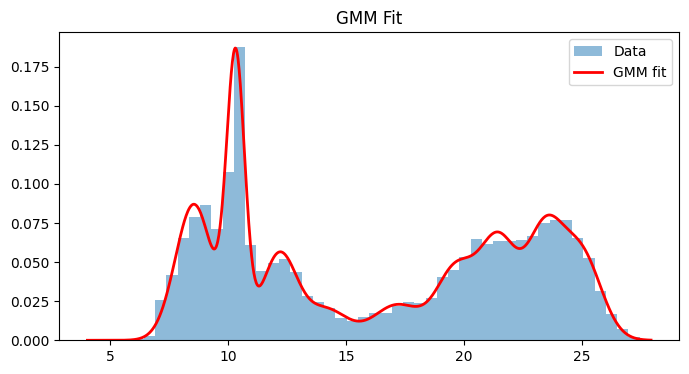

In [17]:
log_dt = np.log(cse['ts_hap'].diff())
log_dt = log_dt[log_dt<np.log(59400*1e9)]

gmm = GaussianMixture(n_components=9, random_state=42)
gmm.fit(log_dt.values.reshape(-1, 1))

log_plot = np.linspace(log_dt.min(), log_dt.max(), 1000).reshape(-1, 1)
log_prob = gmm.score_samples(log_plot)
pdf = np.exp(log_prob)

plt.figure(figsize=(8, 4))
plt.hist(log_dt, bins=50, density=True, alpha=0.5, label='Data')
plt.plot(log_plot, pdf, 'r-', lw=2, label='GMM fit')
plt.legend()
plt.title('GMM Fit')
plt.show()

Best n_components (BIC): 6


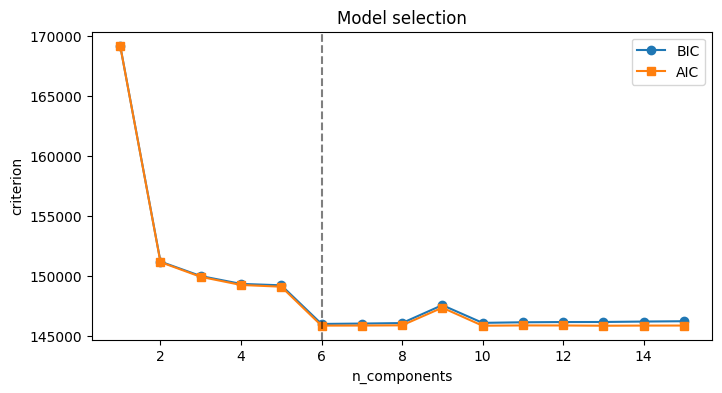

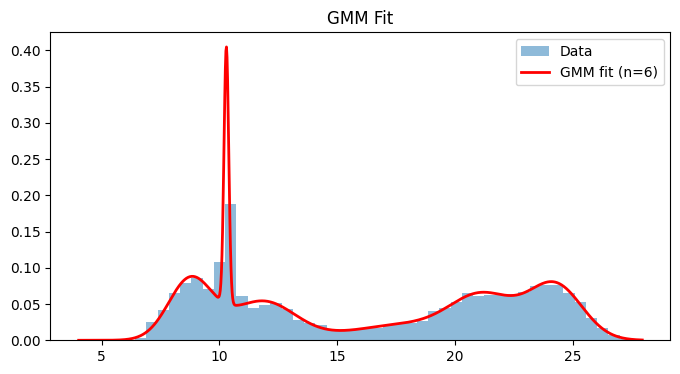

In [18]:
X = log_dt.values.reshape(-1, 1)

# Search over candidate component counts
n_range = range(1, 16)
models = [GaussianMixture(n, random_state=42).fit(X) for n in n_range]
bics = [m.bic(X) for m in models]
aics = [m.aic(X) for m in models]

best_n = n_range[np.argmin(bics)]
best = models[np.argmin(bics)]
print(f"Best n_components (BIC): {best_n}")

# Plot selection criteria
plt.figure(figsize=(8, 4))
plt.plot(n_range, bics, 'o-', label='BIC')
plt.plot(n_range, aics, 's-', label='AIC')
plt.axvline(best_n, color='k', ls='--', alpha=0.5)
plt.xlabel('n_components'); plt.ylabel('criterion'); plt.legend()
plt.title('Model selection'); plt.show()

# Plot the best fit
log_plot = np.linspace(log_dt.min(), log_dt.max(), 1000).reshape(-1, 1)
pdf = np.exp(best.score_samples(log_plot))

plt.figure(figsize=(8, 4))
plt.hist(log_dt, bins=50, density=True, alpha=0.5, label='Data')
plt.plot(log_plot, pdf, 'r-', lw=2, label=f'GMM fit (n={best_n})')
plt.legend(); plt.title('GMM Fit'); plt.show()

/home/leo/jax_lob_sim/.venv/lib/python3.12/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Effective components: 11


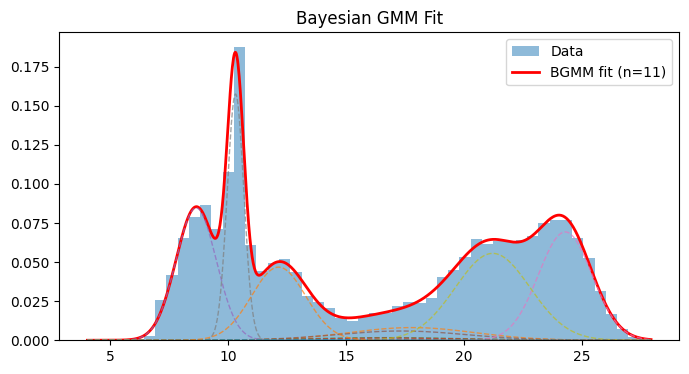

In [ ]:
from sklearn.mixture import BayesianGaussianMixture
from scipy.stats import norm

log_dt = np.log(cse['ts_hap'].diff())
log_dt = log_dt[log_dt < np.log(59400*1e9)]
X = log_dt.values.reshape(-1, 1)

bgmm = BayesianGaussianMixture(
    n_components=20,
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=1e-2,
    random_state=42, max_iter=1000, 
).fit(X)

# Identify effective (non-negligible) components
mask = bgmm.weights_ > 1e-3
print(f"Effective components: {mask.sum()}")

log_plot = np.linspace(log_dt.min(), log_dt.max(), 1000)
xp = log_plot.reshape(-1, 1)
pdf = np.exp(bgmm.score_samples(xp))

plt.figure(figsize=(8, 4))
plt.hist(log_dt, bins=50, density=True, alpha=0.5, label='Data')
plt.plot(log_plot, pdf, 'r-', lw=2, label=f'BGMM fit (n={mask.sum()})')

# Overlay individual components
means = bgmm.means_.ravel()
sds = np.sqrt(bgmm.covariances_.ravel())
weights = bgmm.weights_
for i in np.where(mask)[0]:
    comp = weights[i] * norm.pdf(log_plot, means[i], sds[i])
    plt.plot(log_plot, comp, '--', lw=1, alpha=0.7)

plt.legend()
plt.title('Bayesian GMM Fit')
plt.show()

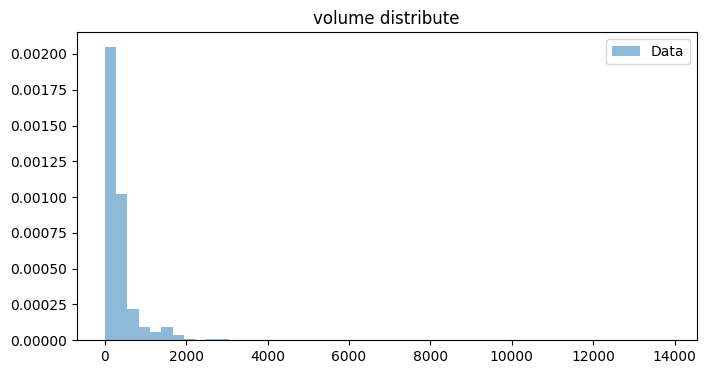

In [57]:
plt.figure(figsize=(8, 4))
plt.hist(cse['size_delta'].values, bins=50, density=True, alpha=0.5, label='Data')
plt.legend()
plt.title('volume distribute')
plt.show()

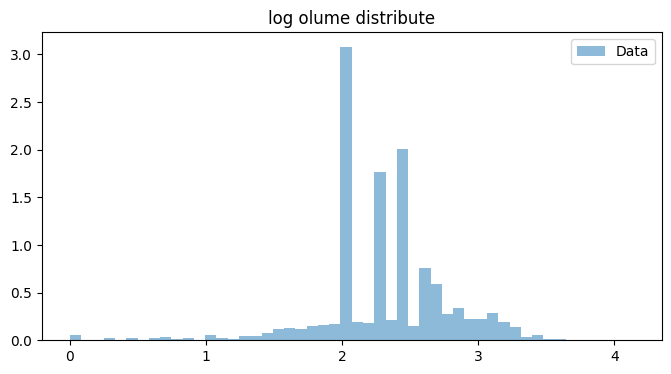

In [34]:
plt.figure(figsize=(8, 4))
plt.hist(np.log10(cse['size_delta'].values), bins=50, density=True, alpha=0.5, label='Data')
plt.legend()
plt.title('log olume distribute')
plt.show()

In [26]:
x = np.log10(cse['size_delta'].values)
x = x[np.isfinite(x)]

# --- you already have these ---
vals, counts = np.unique(np.round(x, 4), return_counts=True)
freq = counts / counts.sum()
spike_vals = vals[freq > 0.01]        # <-- this is your spike_vals
is_spike = np.isin(np.round(x, 4), np.round(spike_vals, 4))

x_cont = x[~is_spike]
p_spike = is_spike.mean()             # total discrete mass
p_cont  = 1 - p_spike

# Discrete table: each spike's probability among ALL data
sv, sc = np.unique(np.round(x[is_spike], 4), return_counts=True)
spike_mass = dict(zip(sv, sc / len(x)))   # sums to p_spike
print("Spike masses:", spike_mass)

Spike masses: {np.float64(2.0): np.float64(0.21676687985906323), np.float64(2.301): np.float64(0.13848569568381142), np.float64(2.4771): np.float64(0.15725173298609782), np.float64(2.6021): np.float64(0.06177473095630194), np.float64(2.699): np.float64(0.04507678756079813), np.float64(2.7782): np.float64(0.01983838229098847), np.float64(2.8451): np.float64(0.022902225115851556), np.float64(2.9031): np.float64(0.015166021983072268), np.float64(3.0): np.float64(0.013519206464708361), np.float64(3.0414): np.float64(0.013404312358775995), np.float64(3.0792): np.float64(0.011259622381371836), np.float64(3.1761): np.float64(0.01034046953391291)}


In [27]:
Xc = x_cont.reshape(-1, 1)
bgmm = BayesianGaussianMixture(
    n_components=20,
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=1e-2,
    random_state=42, max_iter=1000
).fit(Xc)

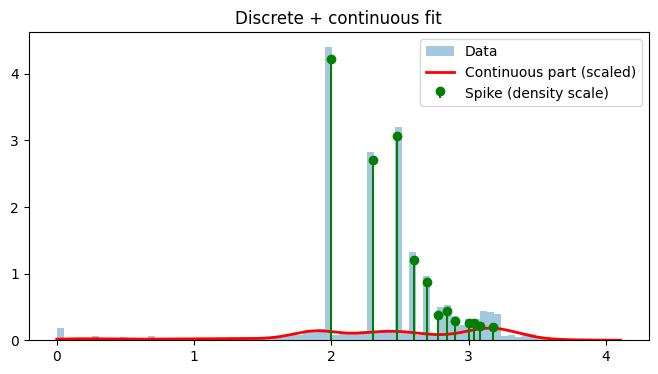

In [31]:
import matplotlib.pyplot as plt
grid = np.linspace(x.min(), x.max(), 1000)
f_cont = np.exp(bgmm.score_samples(grid.reshape(-1,1)))

plt.figure(figsize=(8,4))
plt.hist(x, bins=80, density=True, alpha=0.4, label='Data')
plt.plot(grid, p_cont * f_cont, 'r-', lw=2, label='Continuous part (scaled)')
binwidth = (x.max() - x.min()) / 80      # match your hist bins=80
plt.stem(list(spike_mass.keys()),
         [m / binwidth for m in spike_mass.values()],
         linefmt='g-', markerfmt='go', basefmt=' ', label='Spike (density scale)')
plt.legend(); plt.title('Discrete + continuous fit'); plt.show()

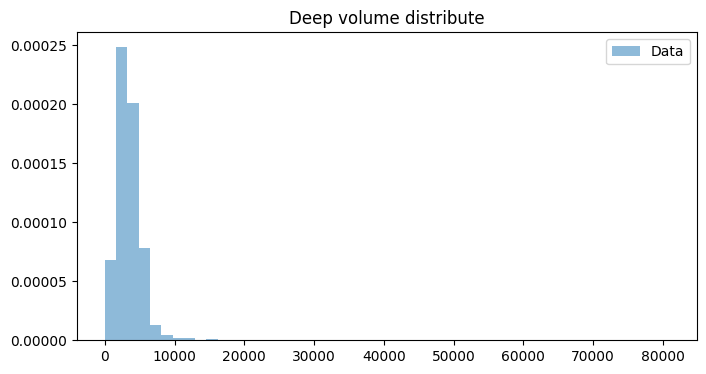

In [32]:
deep_vol = pd.concat([states_df[state_conditions[0]][5], states_df[state_conditions[0]][-5]])
plt.figure(figsize=(8, 4))
plt.hist(deep_vol.values, bins=50, density=True, alpha=0.5, label='Data')
plt.legend()
plt.title('Deep volume distribute')
plt.show()

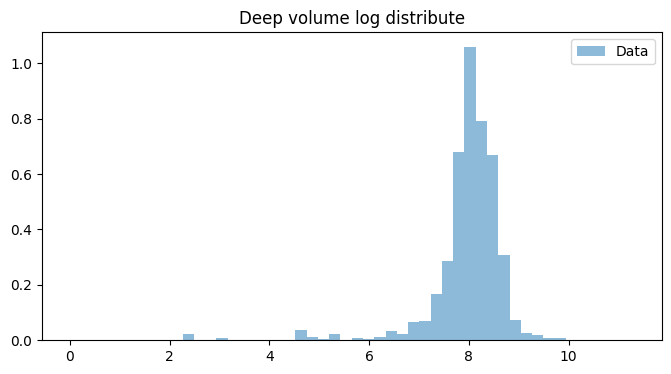

In [33]:
plt.figure(figsize=(8, 4))
plt.hist(np.log(deep_vol[deep_vol>0].values), bins=50, density=True, alpha=0.5, label='Data')
plt.legend()
plt.title('Deep volume log distribute')
plt.show()

mu=3440.8, sigma=2025.6


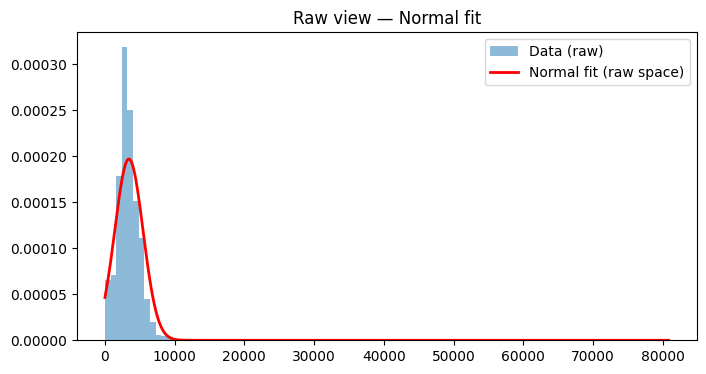

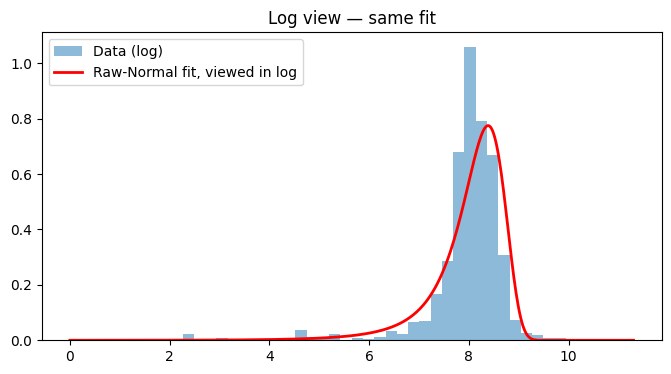

In [35]:
from scipy import stats

x = deep_vol.values
x = x[np.isfinite(x)]

# Fit Normal in RAW space (MLE = sample mean & std)
mu, sigma = x.mean(), x.std()
print(f"mu={mu:.1f}, sigma={sigma:.1f}")

# --- raw view ---
grid_x = np.linspace(x.min(), x.max(), 1000)
pdf_x = stats.norm.pdf(grid_x, mu, sigma)
plt.figure(figsize=(8,4))
plt.hist(x, bins=100, density=True, alpha=0.5, label='Data (raw)')
plt.plot(grid_x, pdf_x, 'r-', lw=2, label='Normal fit (raw space)')
plt.legend(); plt.title('Raw view — Normal fit'); plt.show()

# --- log view: same fit, transformed via Jacobian x ---
xpos = x[x > 0]
lx = np.log(xpos)
grid_l = np.linspace(lx.min(), lx.max(), 500)
# density of log(X) when X~Normal:  f_X(e^l) * e^l
pdf_l = stats.norm.pdf(np.exp(grid_l), mu, sigma) * np.exp(grid_l)
plt.figure(figsize=(8,4))
plt.hist(lx, bins=50, density=True, alpha=0.5, label='Data (log)')
plt.plot(grid_l, pdf_l, 'r-', lw=2, label='Raw-Normal fit, viewed in log')
plt.legend(); plt.title('Log view — same fit'); plt.show()

In [36]:
print(f"P(X<0) under fit: {stats.norm.cdf(0, mu, sigma):.3f}")  # large → raw-Normal is wrong

P(X<0) under fit: 0.045


mu=7.967, sigma=0.807


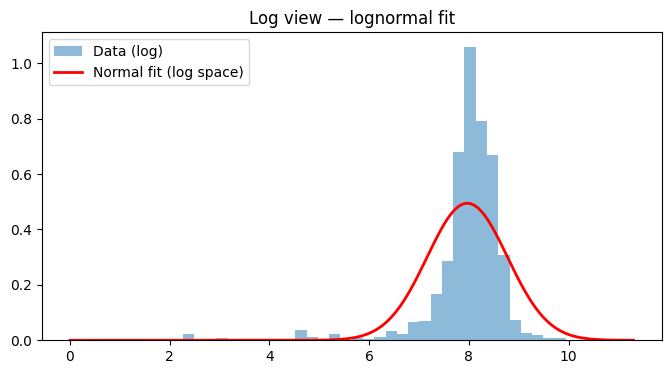

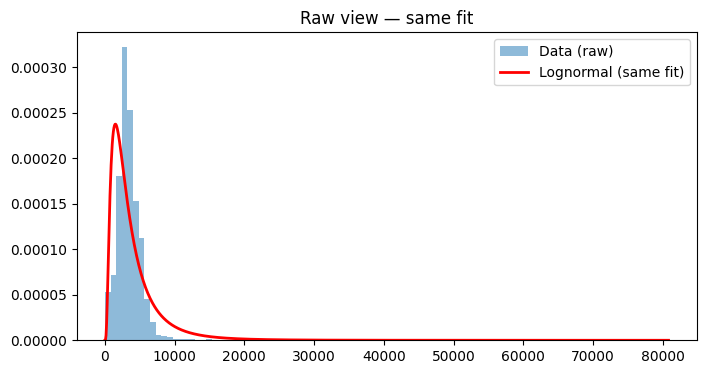

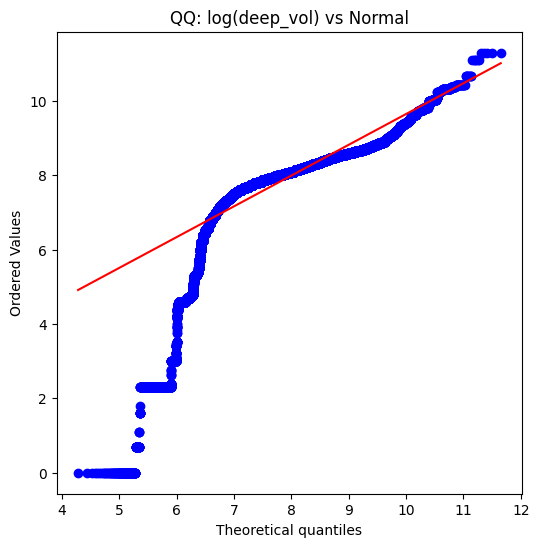

In [37]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

x = deep_vol.values
x = x[np.isfinite(x) & (x > 0)]
lx = np.log(x)

# Fit Normal in LOG space (MLE)
mu, sigma = lx.mean(), lx.std()
print(f"mu={mu:.3f}, sigma={sigma:.3f}")

# --- log view ---
grid_l = np.linspace(lx.min(), lx.max(), 500)
pdf_l = stats.norm.pdf(grid_l, mu, sigma)
plt.figure(figsize=(8,4))
plt.hist(lx, bins=50, density=True, alpha=0.5, label='Data (log)')
plt.plot(grid_l, pdf_l, 'r-', lw=2, label='Normal fit (log space)')
plt.legend(); plt.title('Log view — lognormal fit'); plt.show()

# --- raw view: same fit, Jacobian 1/x ---
grid_x = np.linspace(x.min(), x.max(), 1000)
grid_x = grid_x[grid_x > 0]
pdf_x = stats.norm.pdf(np.log(grid_x), mu, sigma) / grid_x
plt.figure(figsize=(8,4))
plt.hist(x, bins=100, density=True, alpha=0.5, label='Data (raw)')
plt.plot(grid_x, pdf_x, 'r-', lw=2, label='Lognormal (same fit)')
plt.legend(); plt.title('Raw view — same fit'); plt.show()

# --- QQ plot: the real validity check ---
plt.figure(figsize=(6,6))
stats.probplot(lx, dist="norm", sparams=(mu, sigma), plot=plt)
plt.title('QQ: log(deep_vol) vs Normal'); plt.show()

In [39]:
lxr = np.log(x)
print("count in [2,6):", np.sum((lxr >= 2) & (lxr < 6)), "of", len(lxr))
print("fraction:", np.mean((lxr >= 2) & (lxr < 6)))
print("example raw values:", np.sort(x[(lxr>=2)&(lxr<6)])[:20])

count in [2,6): 7620 of 279029
fraction: 0.027308989388199794
example raw values: [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]


means : [8.10519482 6.4778598 ]
sigmas: [0.38415485 1.91254084]
weights: [0.91516459 0.08483541]


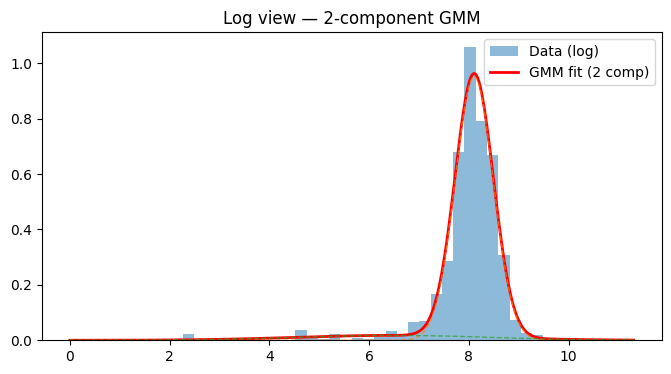

In [ ]:
x = deep_vol.values
x = x[np.isfinite(x) & (x > 0)]
lx = np.log(x).reshape(-1, 1)

gmm = GaussianMixture(n_components=2, random_state=42).fit(lx)

print("means :", gmm.means_.ravel())
print("sigmas:", np.sqrt(gmm.covariances_.ravel()))
print("weights:", gmm.weights_.ravel())

grid = np.linspace(lx.min(), lx.max(), 500)
pdf = np.exp(gmm.score_samples(grid.reshape(-1, 1)))

plt.figure(figsize=(8, 4))
plt.hist(lx.ravel(), bins=50, density=True, alpha=0.5, label='Data (log)')
plt.plot(grid, pdf, 'r-', lw=2, label='GMM fit (2 comp)')
# per-component overlay
m = gmm.means_.ravel(); s = np.sqrt(gmm.covariances_.ravel()); w = gmm.weights_.ravel()
for i in range(2):
    plt.plot(grid, w[i]*norm.pdf(grid, m[i], s[i]), '--', lw=1, alpha=0.7)
plt.legend(); plt.title('Log view — 2-component GMM'); plt.show()


In [47]:
mu_r = np.median(lxr)
sigma_r = (np.percentile(lxr, 84.1) - np.percentile(lxr, 15.9)) / 2  # robust σ

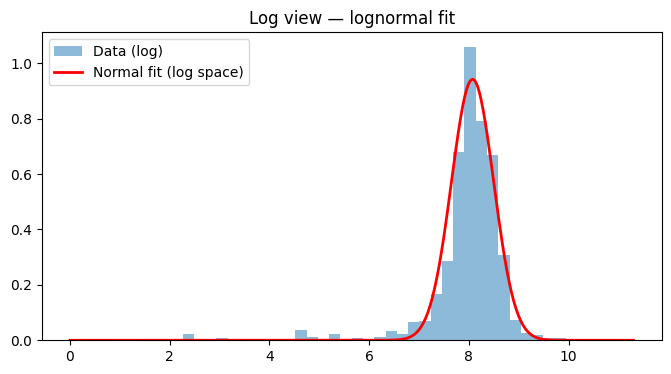

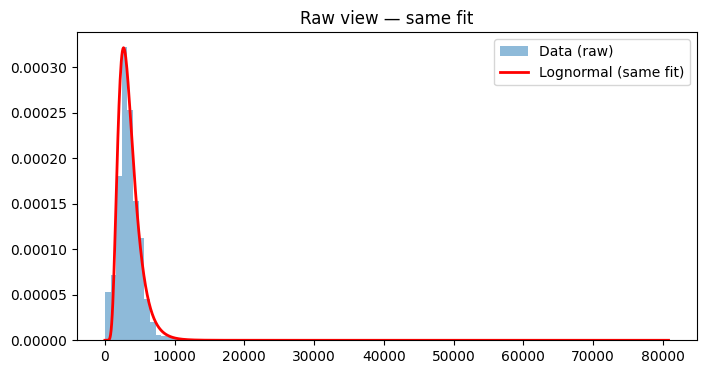

In [50]:
# --- log view ---
grid_l = np.linspace(lx.min(), lx.max(), 500)
pdf_l = stats.norm.pdf(grid_l, mu_r, sigma_r)
plt.figure(figsize=(8,4))
plt.hist(lx, bins=50, density=True, alpha=0.5, label='Data (log)')
plt.plot(grid_l, pdf_l, 'r-', lw=2, label='Normal fit (log space)')
plt.legend(); plt.title('Log view — lognormal fit'); plt.show()

# --- raw view: same fit, Jacobian 1/x ---
grid_x = np.linspace(x.min(), x.max(), 1000)
grid_x = grid_x[grid_x > 0]
pdf_x = stats.norm.pdf(np.log(grid_x), mu_r, sigma_r) / grid_x
plt.figure(figsize=(8,4))
plt.hist(x, bins=100, density=True, alpha=0.5, label='Data (raw)')
plt.plot(grid_x, pdf_x, 'r-', lw=2, label='Lognormal (same fit)')
plt.legend(); plt.title('Raw view — same fit'); plt.show()


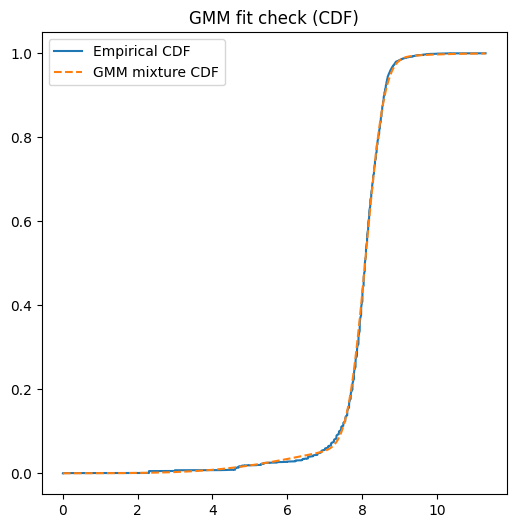

In [51]:
lx1d = np.log(x); lx1d = lx1d[np.isfinite(lx1d)]
xs = np.sort(lx1d)
emp = np.arange(1, len(xs)+1) / len(xs)          # empirical CDF

m = gmm.means_.ravel(); s = np.sqrt(gmm.covariances_.ravel()); w = gmm.weights_.ravel()
mix_cdf = sum(w[i]*norm.cdf(xs, m[i], s[i]) for i in range(len(w)))

plt.figure(figsize=(6,6))
plt.plot(xs, emp, label='Empirical CDF')
plt.plot(xs, mix_cdf, '--', label='GMM mixture CDF')
plt.legend(); plt.title('GMM fit check (CDF)'); plt.show()

In [ ]:
How to validate?
1. probability of every state happened
2. intra day trading volume 
3. Minutely log returns, auto correlation, volatility


Current problem of env:
1. The two different event won't happened in the same time
2. The reconstruction of state
